In [2]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


/Users/ruben/Documents/GitHub/efficient-frontier-portfolio-optimization/.venv-1/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
tickers = ["AAPL", "MSFT", "JPM", "GS", "NVDA"]
start_date = "2021-01-01"
end_date = "2026-01-01"

prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False
)["Adj Close"]

prices.head()


[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,GS,JPM,MSFT,NVDA
Date,,,,,
2021-01-04,125.856712,234.088089,109.491562,208.406525,13.076017
2021-01-05,127.412773,239.326340,110.087334,208.607529,13.366438
2021-01-06,123.123871,252.240891,115.256584,203.198532,12.578444
2021-01-07,127.325226,257.629395,119.041519,208.980942,13.305859
2021-01-08,128.424194,256.242554,119.172943,210.254211,13.238802


In [4]:
returns = prices.pct_change().dropna()
returns.head()


Ticker,AAPL,GS,JPM,MSFT,NVDA
Date,,,,,
2021-01-05,0.012364,0.022377,0.005441,0.000964,0.022210
2021-01-06,-0.033661,0.053962,0.046956,-0.025929,-0.058953
2021-01-07,0.034123,0.021363,0.032839,0.028457,0.057830
2021-01-08,0.008631,-0.005383,0.001104,0.006093,-0.005040
2021-01-11,-0.023249,0.012927,0.014924,-0.009698,0.025966


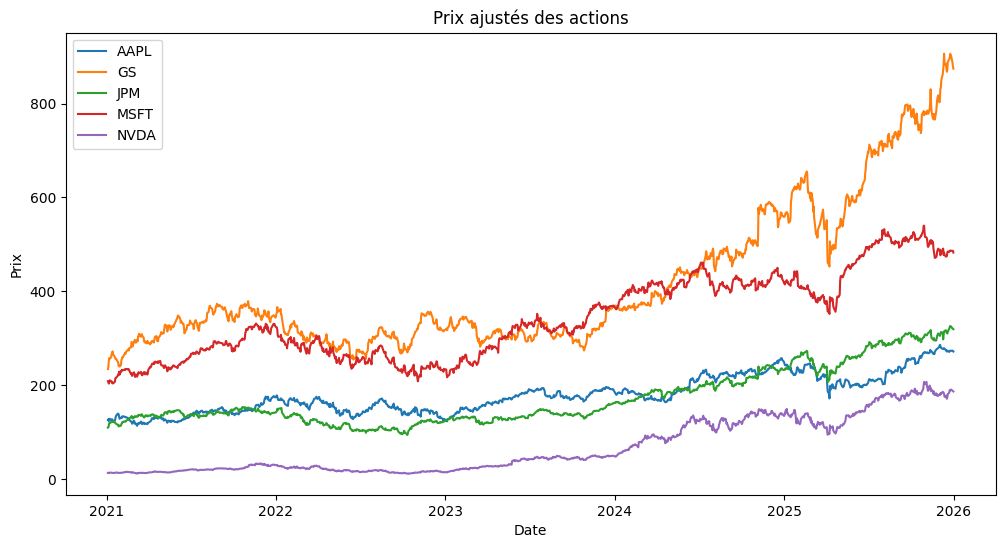

In [5]:
plt.figure(figsize=(12, 6))

for col in prices.columns:
    plt.plot(prices.index, prices[col], label=col)

plt.title("Prix ajustés des actions")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()
plt.show()


In [6]:
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

print("Rendements annualisés :")
display(mean_returns)

print("Matrice de covariance annualisée :")
display(cov_matrix)


Rendements annualisés :


Ticker
AAPL    0.193226
GS      0.302057
JPM     0.244470
MSFT    0.201725
NVDA    0.669495
dtype: float64

Matrice de covariance annualisée :


Ticker,AAPL,GS,JPM,MSFT,NVDA
Ticker,,,,,
AAPL,0.077633,0.030306,0.023363,0.045421,0.075645
GS,0.030306,0.074515,0.051512,0.026122,0.054485
JPM,0.023363,0.051512,0.058926,0.019430,0.040059
MSFT,0.045421,0.026122,0.019430,0.066123,0.084665
NVDA,0.075645,0.054485,0.040059,0.084665,0.272742


In [7]:
num_portfolios = 10000
risk_free_rate = 0.02

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    weights_record.append(weights)

    portfolio_return = np.sum(weights * mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

    results[0, i] = portfolio_return
    results[1, i] = portfolio_volatility
    results[2, i] = sharpe_ratio


In [8]:
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[0, max_sharpe_idx]
max_sharpe_volatility = results[1, max_sharpe_idx]
max_sharpe_weights = weights_record[max_sharpe_idx]

optimal_portfolio = pd.DataFrame({
    "Ticker": tickers,
    "Poids": max_sharpe_weights
})

print("Portefeuille au ratio de Sharpe maximal :")
display(optimal_portfolio)

print(f"Rendement annualisé : {max_sharpe_return:.2%}")
print(f"Volatilité annualisée : {max_sharpe_volatility:.2%}")
print(f"Ratio de Sharpe : {results[2, max_sharpe_idx]:.2f}")


Portefeuille au ratio de Sharpe maximal :


,Ticker,Poids
0,AAPL,0.017089
1,MSFT,0.395634
2,JPM,0.201787
3,GS,0.017561
4,NVDA,0.367928


Rendement annualisé : 42.20%
Volatilité annualisée : 29.02%
Ratio de Sharpe : 1.39


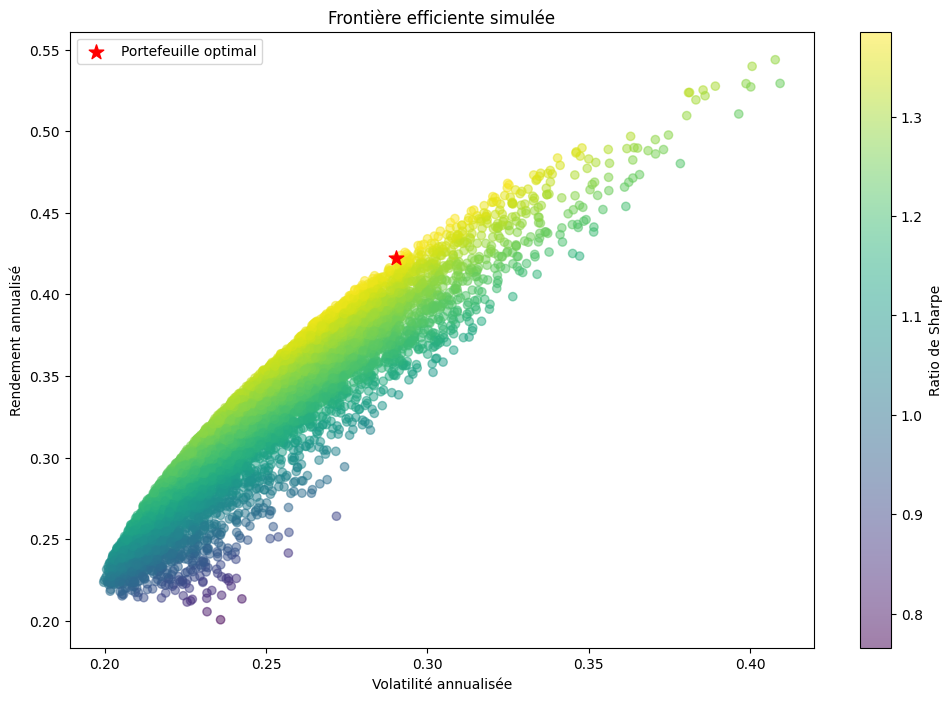

In [9]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    results[1, :],
    results[0, :],
    c=results[2, :],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(scatter, label="Ratio de Sharpe")
plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    color="red",
    s=120,
    marker="*",
    label="Portefeuille optimal"
)

plt.title("Frontière efficiente simulée")
plt.xlabel("Volatilité annualisée")
plt.ylabel("Rendement annualisé")
plt.legend()
plt.show()


In [10]:
optimal_portfolio["Poids (%)"] = optimal_portfolio["Poids"] * 100
optimal_portfolio = optimal_portfolio.sort_values(by="Poids (%)", ascending=False)
optimal_portfolio


,Ticker,Poids,Poids (%)
1,MSFT,0.395634,39.563389
4,NVDA,0.367928,36.792826
2,JPM,0.201787,20.178744
3,GS,0.017561,1.756095
0,AAPL,0.017089,1.708947


In [11]:
print(f"Rendement annualisé du portefeuille optimal : {max_sharpe_return:.2%}")
print(f"Volatilité annualisée du portefeuille optimal : {max_sharpe_volatility:.2%}")
print(f"Ratio de Sharpe du portefeuille optimal : {results[2, max_sharpe_idx]:.2f}")


Rendement annualisé du portefeuille optimal : 42.20%
Volatilité annualisée du portefeuille optimal : 29.02%
Ratio de Sharpe du portefeuille optimal : 1.39


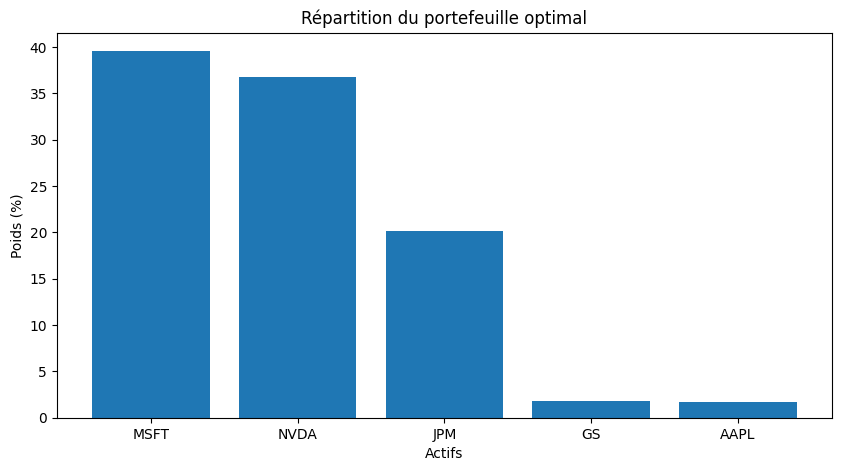

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(optimal_portfolio["Ticker"], optimal_portfolio["Poids (%)"])
plt.title("Répartition du portefeuille optimal")
plt.xlabel("Actifs")
plt.ylabel("Poids (%)")
plt.show()
